In [2]:
import os
from pathlib import Path
import numpy as np
import pickle
import pooch
import tifffile
from careamics.lightning import VAEModule
import matplotlib.pyplot as plt
from microsplit_reproducibility.configs.factory import (
    create_algorithm_config,
    get_likelihood_config,
    get_loss_config,
    get_model_config
)
from microsplit_reproducibility.utils.io import load_checkpoint_path
from microsplit_reproducibility.utils.utils import plot_input_patches
from microsplit_reproducibility.datasets import create_train_val_datasets

# Dataset specific imports...
from microsplit_reproducibility.configs.parameters.custom_dataset_2D import (
    get_microsplit_parameters,
)
from microsplit_reproducibility.configs.data.custom_dataset_2D import get_data_configs
from microsplit_reproducibility.datasets.custom_dataset_2D import get_train_val_data


from usplit.core.tiff_reader import save_tiff, load_tiff

import random
import os
import numpy as np
import torch
import pickle
import ml_collections
import glob
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

from tqdm import tqdm
import numpy as np
from usplit.training import create_dataset, create_model
import matplotlib.pyplot as plt
from usplit.core.loss_type import LossType
from usplit.config_utils import load_config
from usplit.analysis.lvae_utils import get_img_from_forward_output
from usplit.analysis.plot_utils import clean_ax
from usplit.core.data_type import DataType
from usplit.core.psnr import PSNR
from usplit.analysis.plot_utils import get_k_largest_indices,plot_imgs_from_idx
from usplit.core.psnr import PSNR, RangeInvariantPsnr
from usplit.core.data_split_type import DataSplitType
from usplit.analysis.stitch_prediction import stitch_predictions
from usplit.analysis.mmse_prediction import get_dset_predictions
import pdb
from usplit.core.model_type import ModelType
torch.multiprocessing.set_sharing_strategy('file_system')


In [3]:

# %%

# %% [markdown]
# # **Step 2.1:** Data Preparation

# %% [markdown]
# ### OR path to your own data

dataset = "PAVIA_ATN"
# dataset = "HAGEN"
if dataset == "PAVIA_ATN":
    DATA_PATH = Path("/group/jug/aman/Datasets/PAVIA_ATN")
    ckpt_dir= "/home/aman.kukde/Projects/models/paper_models/PaviaATN/ActTub/LeanLC/"
elif dataset == "HAGEN":
    DATA_PATH = Path("/group/jug/aman/Datasets/HAGEN")
    ckpt_dir= "/home/aman.kukde/Projects/models/paper_models/Hagen/MitoVsAct/LeanLC/"

NM_PATH = Path("./noise_models/")

# %% [markdown]
# ### Next, we load the image data to be processed

# %%
# setting up train, validation, and test data configs
img_sz = 64
multiscale_lowres_count = 5
sliding_window_flag = False

train_data_config, val_data_config, test_data_config = get_data_configs(
    image_size=(img_sz, img_sz), num_channels=2, sliding_window_flag= sliding_window_flag, multiscale_lowres_count = multiscale_lowres_count
)
# setting up MicroSplit parametrization
experiment_params = get_microsplit_parameters(
    algorithm = "musplit",
    img_size=(img_sz, img_sz),
    batch_size=32,
    num_epochs=10,
    multiscale_count=multiscale_lowres_count,
    noise_model_path=NM_PATH,
    target_channels=2,
)

# create the dataset
train_dset, val_dset, test_dset, data_stats = create_train_val_datasets(
    datapath=DATA_PATH,
    train_config=train_data_config,
    val_config=val_data_config,
    test_config=test_data_config,
    load_data_func=get_train_val_data,
)

# from usplit.core.tiff_reader import load_tiff
img_win = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/windowed/pred_test_dset_pavia_usplit_windowed.tiff").transpose(0,2,3,1)
img_og = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/original/pred_test_dset_pavia_usplit_og_64.tiff").transpose(0,2,3,1)

# img_win = img_win.transpose((0,2,3,1))
# img_og = img_og.transpose((0,2,3,1))


# from usplit.core.tiff_reader import load_tiff
# img_win = load_tiff(f'/group/jug/aman/results/Results_usplit_64/HAGEN/pred_test_dset_usplit_windowed.tiff').transpose(0,2,3,1)
# img_og = load_tiff(f'/group/jug/aman/results/Results_usplit_64/HAGEN/pred_test_dset_usplit_og.tiff').transpose(0,2,3,1)


import numpy as np

def array_stats(arr):
    return {
        'shape': arr.shape,
        'dtype': arr.dtype,
        'min': np.min(arr),
        'max': np.max(arr),
        'mean': np.mean(arr),
        'std': np.std(arr),
        'median': np.median(arr),
        'percentile_1': np.percentile(arr, 1),
        'percentile_99': np.percentile(arr, 99),
        'nan_count': np.isnan(arr).sum()
    }




Dataclass is <class 'careamics.lvae_training.dataset.lc_dataset.LCMultiChDloader'>

Padding is not used with this alignement style

Padding is not used with this alignement style

Padding is not used with this alignement style


/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')
/home/aman.kukde/Projects_2/uSplit/usplit/core/tiff_reader.py:9: FutureWarning: The plugin infrastructure in `skimage.io` and the parameter `plugin` are deprecated since version 0.25 and will be removed in 0.27 (or later). To avoid this warning, please do not use the parameter `plugin`. Instead, use `imageio` or other I/O packages directly. See also `imread`.
  return imread(path, plugin='tifffile')


In [4]:

# from usplit.core.tiff_reader import load_tiff
# img_win = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/windowed/pred_test_dset_pavia_usplit_windowed.tiff").transpose(0,2,3,1)
# img_og = load_tiff("/group/jug/aman/results/Results_usplit_64/PAVIA_ATN/original/pred_test_dset_pavia_usplit_og_64.tiff").transpose(0,2,3,1)

In [5]:
from collections import defaultdict
import numpy as np
import cv2
from skimage.metrics import structural_similarity as ssim
from typing import Optional

def get_tile_edges(img_shape, grid_size):
    vertical_edges = list(range(grid_size, img_shape[1], grid_size))
    horizontal_edges = list(range(grid_size, img_shape[0], grid_size))
    return vertical_edges, horizontal_edges


def mse_across_edges(img: np.ndarray, ground_truth: Optional[np.ndarray], grid_size: int, width: int = 4):
    if ground_truth is None:
        return None

    vert_edges, horiz_edges = get_tile_edges(img.shape, grid_size)
    vert_mse_vals = []
    horiz_mse_vals = []

    for c in vert_edges:
        pred_strip = img[:, c - width // 2:c + width // 2]
        gt_strip = ground_truth[:, c - width // 2:c + width // 2]
        vert_mse_vals.append(np.mean((pred_strip - gt_strip) ** 2))

    for r in horiz_edges:
        pred_strip = img[r - width // 2:r + width // 2, :]
        gt_strip = ground_truth[r - width // 2:r + width // 2, :]
        horiz_mse_vals.append(np.mean((pred_strip - gt_strip) ** 2))

    explanation = ("MSE quantifies pixel-wise squared differences.\n"
                   "Higher MSE at tile edges indicates artifacts or discontinuities.")

    return {
        "vertical_edge_mse_mean": np.mean(vert_mse_vals),
        "horizontal_edge_mse_mean": np.mean(horiz_mse_vals),
        "explanation": explanation
    }


def fourier_periodicity(img: np.ndarray, grid_size: int):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = np.abs(fshift)

    rows, cols = img.shape
    center_row, center_col = rows // 2, cols // 2
    freq_row = rows // grid_size
    freq_col = cols // grid_size

    mag_vals = []
    for k in range(1, min(freq_row, freq_col)):
        r_pos = center_row + k * freq_row
        r_neg = center_row - k * freq_row
        c_pos = center_col + k * freq_col
        c_neg = center_col - k * freq_col

        if 0 <= r_pos < rows: mag_vals.append(magnitude_spectrum[r_pos, center_col])
        if 0 <= r_neg < rows: mag_vals.append(magnitude_spectrum[r_neg, center_col])
        if 0 <= c_pos < cols: mag_vals.append(magnitude_spectrum[center_row, c_pos])
        if 0 <= c_neg < cols: mag_vals.append(magnitude_spectrum[center_row, c_neg])

    mean_at_tile_freq = np.mean(mag_vals)
    mean_overall = np.mean(magnitude_spectrum)

    explanation = ("Fourier magnitude spikes at tile frequency indicate periodic tiling artifacts.\n"
                   "Higher ratio means stronger periodic artifact presence.")

    return {
        "fourier_tile_freq_magnitude_ratio": mean_at_tile_freq / (mean_overall + 1e-8),
        "explanation": explanation
    }


def compute_all_metrics_batch(imgs: np.ndarray, grid_size: int, ground_truths: Optional[np.ndarray] = None):
    """
    imgs: numpy array of shape (n, h, w, c)
    ground_truths: same shape as imgs or None
    Returns: dict[image_id][channel_id] = metrics dict
    """
    assert imgs.ndim == 4, "Input images should have shape (n, H, W, C)"
    n, h, w, c = imgs.shape

    results = {}

    for i in range(n):
        img_result = {}
        for ch in range(c):
            pred = imgs[i, :, :, ch]
            gt = ground_truths[i, :, :, ch] if ground_truths is not None else None

            metrics = {}
            mse_res = mse_across_edges(pred, gt, grid_size)
            if mse_res: metrics['mse'] = mse_res

            fourier_res = fourier_periodicity(pred, grid_size)
            if fourier_res: metrics['fourier'] = fourier_res

            img_result[f'channel_{ch}'] = metrics

        # Compute cumulative averages
        cumulative = {}
        for metric_group in ['mse', 'fourier']:
            combined = defaultdict(list)
            for ch in range(c):
                for key, val in img_result[f'channel_{ch}'].get(metric_group, {}).items():
                    if key != 'explanation':
                        combined[key].append(val)
            if combined:
                cumulative[metric_group] = {
                    key: float(np.mean(vals)) for key, vals in combined.items()
                }
                # Add explanation from one of the channels
                for ch in range(c):
                    if 'explanation' in img_result[f'channel_{ch}'].get(metric_group, {}):
                        cumulative[metric_group]['explanation'] = img_result[f'channel_{ch}'][metric_group]['explanation']
                        break

        img_result['cumulative'] = cumulative
        results[f'image_{i}'] = img_result

    return results


def print_comparative_report(metrics_og: dict, metrics_win: dict):
    print("======= COMPARATIVE METRIC REPORT =======\n")

    delta_accumulator = defaultdict(list)
    og_accumulator = defaultdict(list)
    win_accumulator = defaultdict(list)

    for image_key in sorted(metrics_og.keys()):
        print(f"\n>>> {image_key.upper()}")
        for channel_key in sorted(metrics_og[image_key].keys()):
            print(f"\n  -- {channel_key.upper()} --")
            og_metrics_group = metrics_og[image_key][channel_key]
            win_metrics_group = metrics_win.get(image_key, {}).get(channel_key, {})

            for group_name, og_metrics in og_metrics_group.items():
                win_metrics = win_metrics_group.get(group_name, {})
                print(f"\n    [{group_name.upper()} METRICS]")
                for metric_name, og_val in og_metrics.items():
                    if metric_name == "explanation":
                        continue
                    win_val = win_metrics.get(metric_name)
                    if win_val is None:
                        continue
                    delta = win_val - og_val

                    delta_accumulator[f"{group_name}/{metric_name}"].append(delta)
                    og_accumulator[f"{group_name}/{metric_name}"].append(og_val)
                    win_accumulator[f"{group_name}/{metric_name}"].append(win_val)

                    print(f"    {metric_name:<35}: og = {og_val:.4f} | win = {win_val:.4f} | Δ = {delta:+.4f}")

                explanation = og_metrics.get("explanation", win_metrics.get("explanation", ""))
                if explanation:
                    print("      Explanation:", explanation)

    print("\n======= SUMMARY: CUMULATIVE AVERAGE METRICS =======")
    for metric_key in sorted(delta_accumulator.keys()):
        mean_og = np.mean(og_accumulator[metric_key])
        mean_win = np.mean(win_accumulator[metric_key])
        mean_delta = np.mean(delta_accumulator[metric_key])
        print(f"{metric_key:<45}: og = {mean_og:.4f} | win = {mean_win:.4f} | Δ = {mean_delta:+.4f}")


In [ ]:
metrics_win = compute_all_metrics_batch(img_win, 
                          grid_size=32, 
                          ground_truths=test_dset._data
                          )
metrics_og = compute_all_metrics_batch(img_og, 
                          grid_size=32, 
                          ground_truths=test_dset._data
                          )

In [ ]:
def print_channelwise_summary(metrics_og: dict, metrics_win: dict):
    from collections import defaultdict
    import numpy as np

    print("======= COMPARATIVE METRIC REPORT =======\n")

    # channel -> metric_group/metric_name -> list of values
    agg = {
        "og": defaultdict(lambda: defaultdict(list)),
        "win": defaultdict(lambda: defaultdict(list)),
        "delta": defaultdict(lambda: defaultdict(list)),
        "explanations": defaultdict(dict)
    }

    for image_key in metrics_og:
        for channel_key in metrics_og[image_key]:
            if channel_key == "cumulative":
                continue

            ch_id = int(channel_key.split("_")[1])
            og_metrics_group = metrics_og[image_key][channel_key]
            win_metrics_group = metrics_win[image_key][channel_key]

            for group_name in og_metrics_group:
                og_metrics = og_metrics_group[group_name]
                win_metrics = win_metrics_group.get(group_name, {})

                for metric_name, og_val in og_metrics.items():
                    if metric_name == "explanation":
                        continue
                    win_val = win_metrics.get(metric_name)
                    if win_val is None:
                        continue
                    delta = win_val - og_val

                    agg["og"][ch_id][f"{group_name}/{metric_name}"].append(og_val)
                    agg["win"][ch_id][f"{group_name}/{metric_name}"].append(win_val)
                    agg["delta"][ch_id][f"{group_name}/{metric_name}"].append(delta)

                # Save explanation once per group
                if "explanation" in og_metrics:
                    agg["explanations"][ch_id][group_name] = og_metrics["explanation"]

    # Print summary
    for ch_id in sorted(agg["og"].keys()):
        print(f"\n>>> CHANNEL {ch_id} SUMMARY")

        for metric_key in sorted(agg["og"][ch_id].keys()):
            og_vals = agg["og"][ch_id][metric_key]
            win_vals = agg["win"][ch_id][metric_key]
            deltas = agg["delta"][ch_id][metric_key]

            mean_og = np.mean(og_vals)
            mean_win = np.mean(win_vals)
            mean_delta = np.mean(deltas)

            print(f"{metric_key:<40}: og = {mean_og:.4f} | win = {mean_win:.4f} | Δ = {mean_delta:+.4f}")

        # Explanations grouped by metric group
        print("\n  Explanation:")
        for group, explanation in agg["explanations"][ch_id].items():
            print(f"    [{group.upper()}]: {explanation}")


In [ ]:
print_channelwise_summary(metrics_og, metrics_win)

In [ ]:
x,y,w = 2160,1578,128

In [ ]:
import numpy as np
from scipy.ndimage import sobel

def compute_edge_discontinuities_with_band(images, tile_size=32, margin=16, band_width=4):
    """
    Computes edge discontinuity maps using gradients around tile seams.

    Parameters:
        images (np.ndarray): Input image array of shape (n, H, W, C)
        tile_size (int): Size of each tile
        margin (int): Crop margin on each side
        band_width (int): Number of columns/rows to include across each seam (centered around edge)

    Returns:
        np.ndarray: Edge map array of shape (n, H-2*margin, W-2*margin, C)
    """
    n, H, W, C = images.shape
    h_crop, w_crop = H - 2*margin, W - 2*margin
    edge_maps = np.zeros((n, h_crop, w_crop, C), dtype=images.dtype)
    half_bw = band_width // 2

    for i in range(n):
        for c in range(C):
            img = images[i, margin:-margin, margin:-margin, c]  # (H', W')

            edge_map = np.zeros_like(img)

            # Horizontal seam bands (vertical gradients)
            for col in range(tile_size - half_bw, img.shape[1], tile_size):
                if col - half_bw < 0 or col + half_bw >= img.shape[1]:
                    continue
                band = img[:, col - half_bw: col + half_bw + 1]  # shape: (H', band_width)
                grad = np.abs(np.gradient(band, axis=1))  # gradient across columns
                edge_map[:, col - half_bw: col + half_bw + 1] += grad

            # Vertical seam bands (horizontal gradients)
            for row in range(tile_size - half_bw, img.shape[0], tile_size):
                if row - half_bw < 0 or row + half_bw >= img.shape[0]:
                    continue
                band = img[row - half_bw: row + half_bw + 1, :]  # shape: (band_width, W')
                grad = np.abs(np.gradient(band, axis=0))  # gradient across rows
                edge_map[row - half_bw: row + half_bw + 1, :] += grad

            edge_maps[i, :, :, c] = edge_map

    return edge_maps

In [ ]:
import numpy as np

def compute_edge_discontinuities_fixed(images, tile_size=32, margin=16, abs_flag=True):
    """
    Computes edge discontinuity maps (horizontal + vertical tile seams) for 4D image array.

    Parameters:
        images (np.ndarray): Array of shape (n, H, W, C)
        tile_size (int): Size of each tile (default 32)
        margin (int): Margin to crop on all sides (default 16)

    Returns:
        np.ndarray: Array of shape (n, H-2*margin, W-2*margin, C) with edge maps
    """
    n, H, W, C = images.shape
    h_crop, w_crop = H - 2*margin, W - 2*margin
    edge_maps = np.full((n, h_crop, w_crop, C), -np.inf, dtype=images.dtype)

    for i in range(n):
        for c in range(C):
            # Crop margins
            img = images[i, margin:-margin, margin:-margin, c]  # shape: (H', W')

            # Horizontal edges
            l = img[:, tile_size - 1::tile_size]
            r = img[:, tile_size::tile_size]
            h_zeros = np.zeros_like(img)
            if abs_flag : h_zeros[:, tile_size - 1::tile_size][:, :-1] = np.abs(r - l[:, :-1])
            else: h_zeros[:, tile_size - 1::tile_size][:, :-1] = r - l[:, :-1]

            # Vertical edges
            t = img[tile_size - 1::tile_size, :]
            b = img[tile_size::tile_size, :]
            v_zeros = np.zeros_like(img)
            if abs_flag : v_zeros[tile_size - 1::tile_size, :][:-1, :] = np.abs(b - t[:-1, :])
            else: v_zeros[tile_size - 1::tile_size, :][:-1, :] = b - t[:-1, :]

            # Combine edges
            edge_maps[i, :, :, c] = (h_zeros + v_zeros)/ 2.0

    return edge_maps


In [ ]:
edge_map_win_abs = compute_edge_discontinuities_fixed(img_win, tile_size=32, margin=16)
edge_map_og_abs = compute_edge_discontinuities_fixed(img_og, tile_size=32, margin=16)
edge_map_win = compute_edge_discontinuities_fixed(img_win, tile_size=32, margin=16,abs_flag= False)
edge_map_og = compute_edge_discontinuities_fixed(img_og, tile_size=32, margin=16,abs_flag= False)

## GRADIENT CALCULATIONS

In [ ]:
img_win.shape

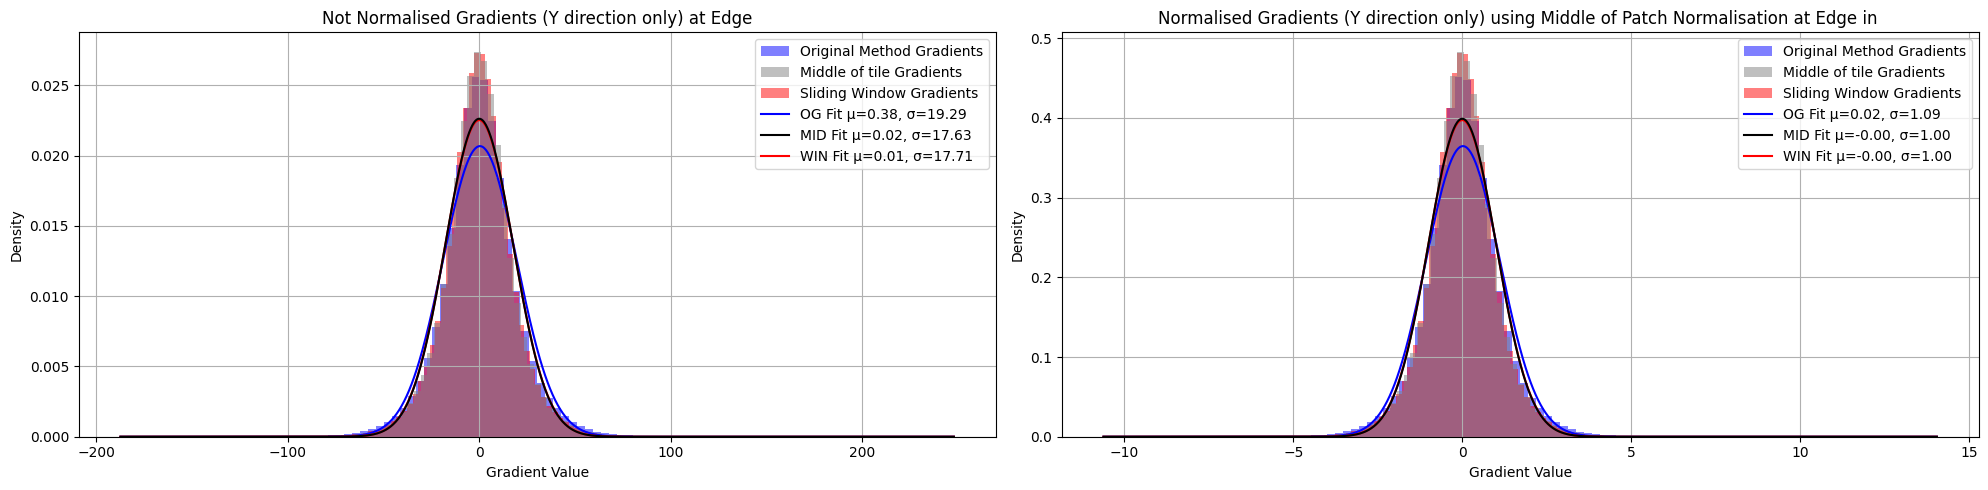

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm


img_win_ = img_win[:,16:-16,16:-16,:]
img_og_ = img_og[:,16:-16,16:-16,:]
grad_x_w =  img_win_[:, :, 1:, :] - img_win_[:, :, :-1, :]   # horizontal (width direction)
grad_y_w =  img_win_[:, 1:, :, :] - img_win_[:, :-1, :, :]   # vertical (height direction)
grad_x_og =  img_og_[:, :, 1:, :] - img_og_[:, :, :-1, :]   # horizontal (width direction)
grad_y_og =  img_og_[:, 1:,:, :] - img_og_[:,:-1,:, :]   # vertical (height direction)
grad_x_og.shape, grad_y_og.shape, grad_x_w.shape, grad_y_w.shape
# Helper function to concatenate x and y gradients
def combine_gradients_xy(grad_x, grad_y,index,):
    return np.concatenate([
        grad_x[:, :, index::32, 1].flatten(),
        grad_y[:, index::32, :, 1].flatten()
    ])
# Get gradients for Original and Windowed methods
def fit_gauss(data_og,data_mid,data_win, index_, fig, axs):
        mu_og, std_og = norm.fit(data_og)
        mu_win, std_win = norm.fit(data_win)
        mu_mid, std_mid = norm.fit(data_mid)

        axs[0].set_title(f"Not Normalised Gradients (Y direction only) at Edge")#{index_}")
        bins = 100
        range_min = min(data_og.min(), data_win.min(), data_mid.min())
        range_max = max(data_og.max(), data_win.max(), data_mid.max())
        x = np.linspace(range_min, range_max, 1000)

        # Histograms
        axs[0].hist(data_og, bins=bins, density=True, alpha=0.5, label='Original Method Gradients', color='blue')
        axs[0].hist(data_win, bins=bins, density=True, alpha=0.5, label='Sliding Window Gradients', color='red')
        axs[0].hist(data_mid, bins=bins, density=True, alpha=0.5, label='Middle of tile Gradients', color='gray')

        # Fitted Gaussian PDFs
        axs[0].plot(x, norm.pdf(x, mu_og, std_og), 'b-', label=f'OG Fit μ={mu_og:.2f}, σ={std_og:.2f}')
        axs[0].plot(x, norm.pdf(x, mu_win, std_win), 'r-', label=f'WIN Fit μ={mu_win:.2f}, σ={std_win:.2f}')
        axs[0].plot(x, norm.pdf(x, mu_mid, std_mid), 'k-', label=f'MID Fit μ={mu_mid:.2f}, σ={std_mid:.2f}')

        # Reorder legend
        handles, labels = axs[0].get_legend_handles_labels()
        order = [labels.index('Original Method Gradients'),
                labels.index('Middle of tile Gradients'),
                labels.index('Sliding Window Gradients'),
                labels.index(f'OG Fit μ={mu_og:.2f}, σ={std_og:.2f}'),
                labels.index(f'MID Fit μ={mu_mid:.2f}, σ={std_mid:.2f}'),
                labels.index(f'WIN Fit μ={mu_win:.2f}, σ={std_win:.2f}')]
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        axs[0].legend(handles, labels)

        axs[0].set_xlabel("Gradient Value")
        axs[0].set_ylabel("Density")
        axs[0].grid(True)


        # Flatten your gradient data for second plot
        data_og = grad_matrix_og_
        data_win = grad_matrix_win_
        data_mid = grads_middle

        # Fit Gaussians
        mu_og, std_og = norm.fit(data_og)
        mu_win, std_win = norm.fit(data_win)
        mu_mid, std_mid = norm.fit(data_mid)


        axs[1].set_title(f"Normalised Gradients (Y direction only) using Middle of Patch Normalisation at Edge in ")#{index_}")

        bins = 100
        range_min = min(data_og.min(), data_win.min(), data_mid.min())
        range_max = max(data_og.max(), data_win.max(), data_mid.max())
        x = np.linspace(range_min, range_max, 1000)

        # Histograms
        axs[1].hist(data_og, bins=bins, density=True, alpha=0.5, label='Original Method Gradients', color='blue')
        axs[1].hist(data_win, bins=bins, density=True, alpha=0.5, label='Sliding Window Gradients', color='red')
        axs[1].hist(data_mid, bins=bins, density=True, alpha=0.5, label='Middle of tile Gradients', color='gray')

        # Fitted Gaussian PDFs
        axs[1].plot(x, norm.pdf(x, mu_og, std_og), 'b-', label=f'OG Fit μ={mu_og:.2f}, σ={std_og:.2f}')
        axs[1].plot(x, norm.pdf(x, mu_win, std_win), 'r-', label=f'WIN Fit μ={mu_win:.2f}, σ={std_win:.2f}')
        axs[1].plot(x, norm.pdf(x, mu_mid, std_mid), 'k-', label=f'MID Fit μ={mu_mid:.2f}, σ={std_mid:.2f}')

        # Reorder legend for second plot
        handles, labels = axs[1].get_legend_handles_labels()
        order = [labels.index('Original Method Gradients'),
                labels.index('Middle of tile Gradients'),
                labels.index('Sliding Window Gradients'),
                labels.index(f'OG Fit μ={mu_og:.2f}, σ={std_og:.2f}'),
                labels.index(f'MID Fit μ={mu_mid:.2f}, σ={std_mid:.2f}'),
                labels.index(f'WIN Fit μ={mu_win:.2f}, σ={std_win:.2f}')]
        handles = [handles[i] for i in order]
        labels = [labels[i] for i in order]
        axs[1].legend(handles, labels)

        axs[1].set_xlabel("Gradient Value")
        axs[1].set_ylabel("Density")
        axs[1].grid(True)

        

def normalise(arr, mean, std):
        return (arr - mean) / std

fig, axs = plt.subplots(1, 2, figsize=(20, 5))
index = 15
# grad_og_mid = combine_gradients_xy(grad_x_og, grad_y_og,index=index)
# grad_win_mid = combine_gradients_xy(grad_x_w, grad_y_w,index=index)

grad_og_mid = grad_x_og[:, :, index::32, 1].flatten()
grad_win_mid = grad_x_w[:, :, index::32, 1].flatten()

# grad_og_mid = grad_y_og[:, index::32, :, 1].flatten()
# grad_win_mid = grad_y_w[:, index::32, :, 1].flatten()

grads_middle_w_og_ch1 = np.concatenate([grad_og_mid, grad_win_mid], axis=0)
mean = grads_middle_w_og_ch1.mean()
std = grads_middle_w_og_ch1.std()

i = 31
# grad_og = combine_gradients_xy(grad_x_og, grad_y_og,index = i)
# grad_win = combine_gradients_xy(grad_x_w, grad_y_w,index = i)

grad_og = grad_x_og[:, :, i::32, 1].flatten()
grad_win = grad_x_w[:, :, i::32, 1].flatten()

# grad_og = grad_y_og[:, i::32, :, 1].flatten()
# grad_win = grad_y_w[:, i::32, :, 1].flatten()


grad_matrix_og_ = normalise(grad_og, mean, std)
grad_matrix_win_ = normalise(grad_win, mean, std)
grads_middle = normalise(grads_middle_w_og_ch1, mean, std)

# Flatten your gradient data
data_og = grad_og
data_win = grad_win
data_mid = grads_middle_w_og_ch1

# Fit Gaussians and plot
fit_gauss(grad_og, grads_middle_w_og_ch1, grad_win, i , fig,axs)
plt.tight_layout()
plt.show()

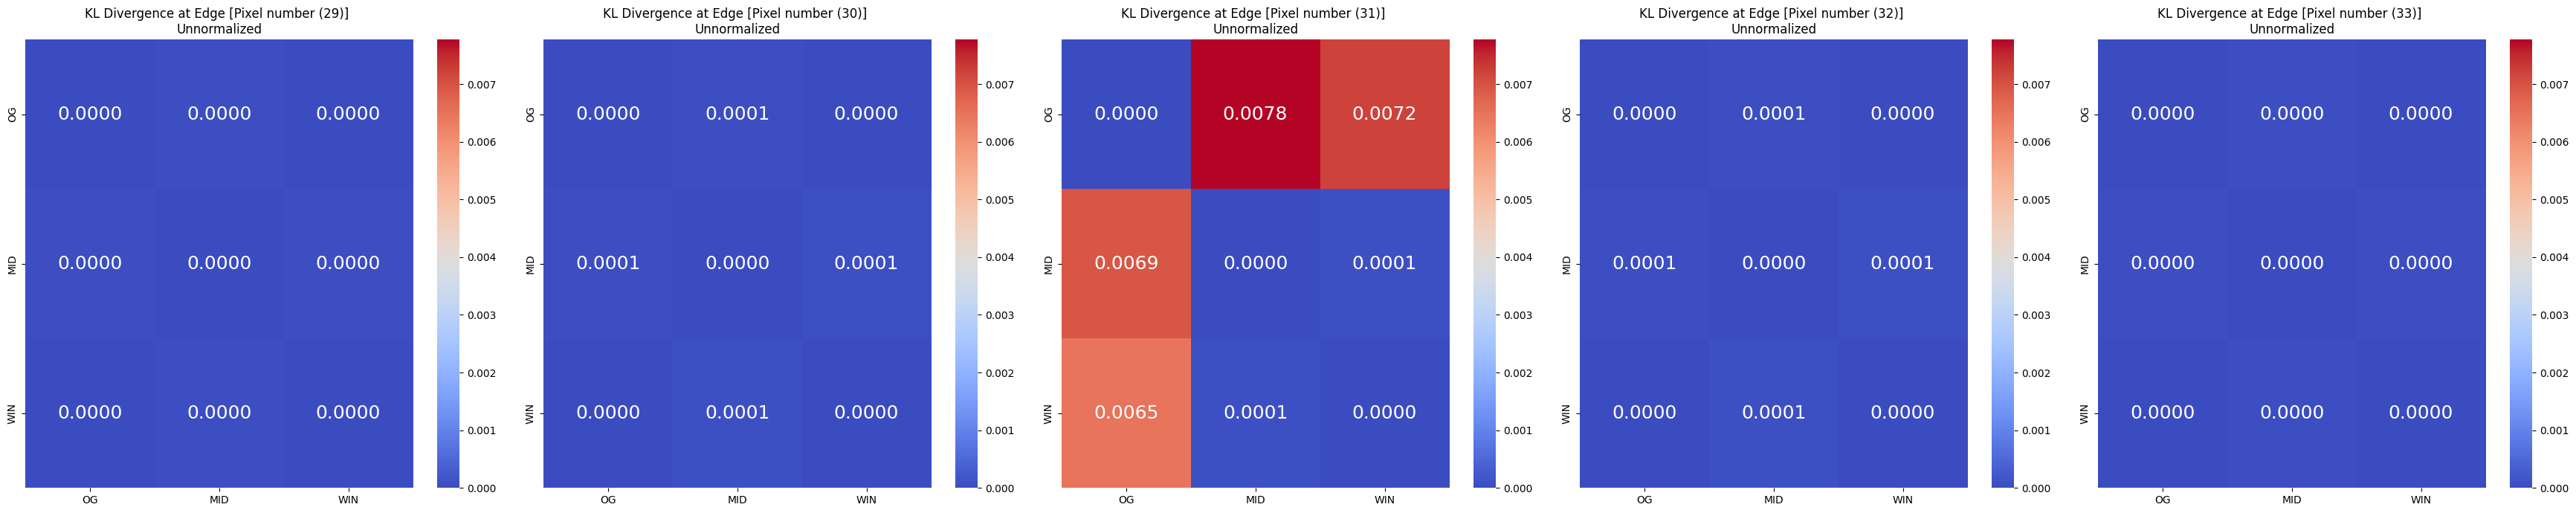

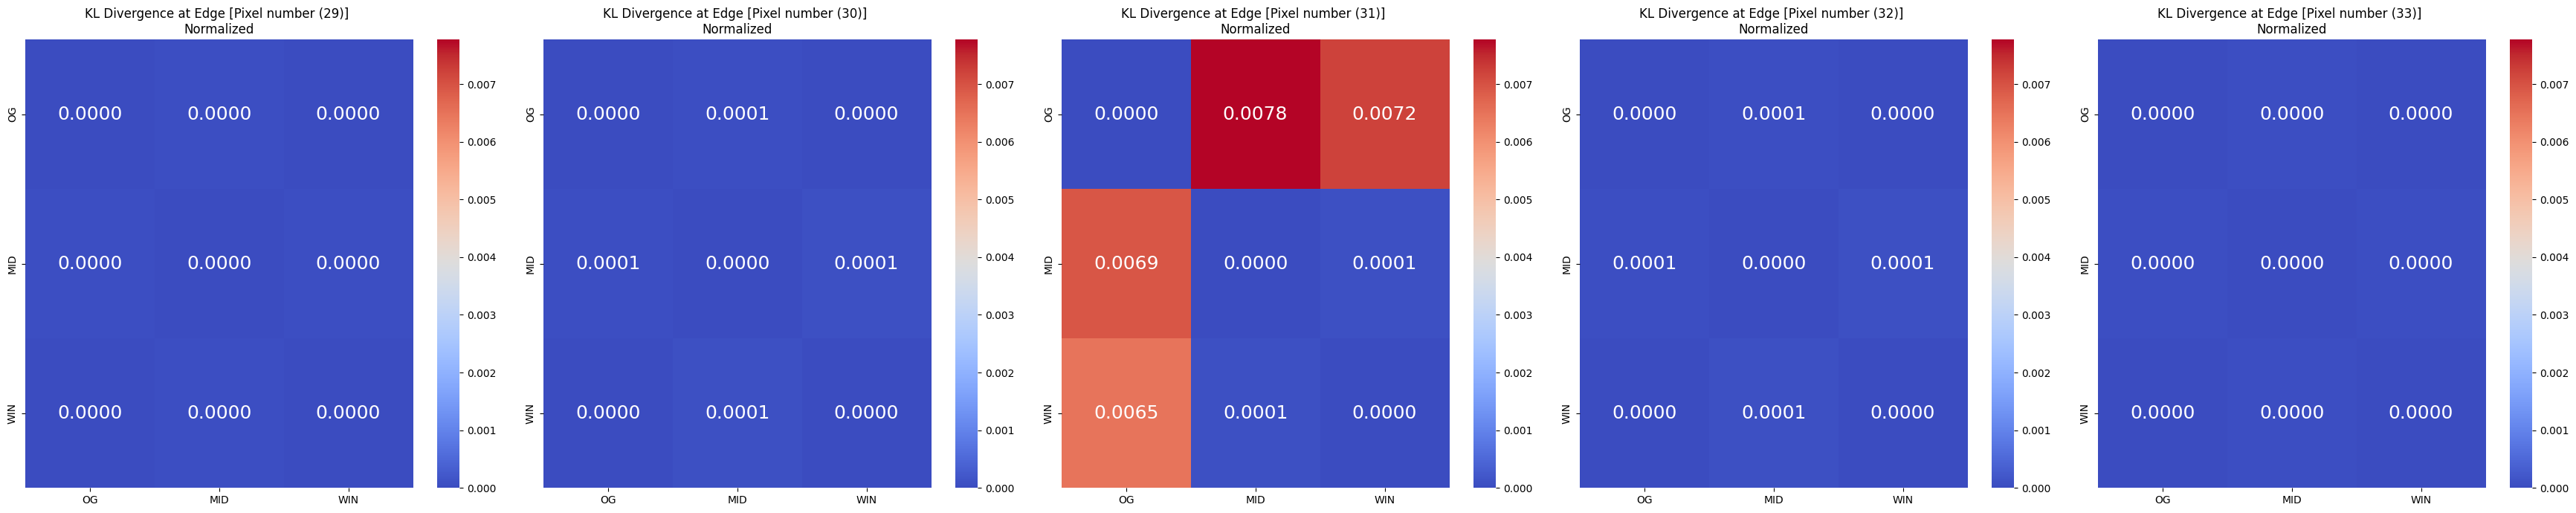

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

methods_simple = ['OG', 'MID', 'WIN']

i_values = range(29, 34)
stats = []

for idx, i in enumerate(i_values):
    grad_og = combine_gradients_xy(grad_x_og, grad_y_og, i)
    grad_win = combine_gradients_xy(grad_x_w, grad_y_w, i)

    mean_mid = grads_middle_w_og_ch1.mean()
    std_mid = grads_middle_w_og_ch1.std()

    grad_matrix_og_ = normalise(grad_og, mean_mid, std_mid)
    grad_matrix_win_ = normalise(grad_win, mean_mid, std_mid)
    grads_middle = normalise(grads_middle_w_og_ch1, mean_mid, std_mid)

    # Method Gaussians raw
    mu_og, std_og = norm.fit(grad_og)
    mu_win, std_win = norm.fit(grad_win)
    mu_mid, std_mid = norm.fit(grads_middle_w_og_ch1)

    # Fit Gaussians normalized
    mu_og_n, std_og_n = norm.fit(grad_matrix_og_)
    mu_win_n, std_win_n = norm.fit(grad_matrix_win_)
    mu_mid_n, std_mid_n = norm.fit(grads_middle)

    # Store stats
    stats.extend([
        {'i': i, 'Method': 'OG Raw', 'Mean': mu_og, 'StdDev': std_og},
        {'i': i, 'Method': 'WIN Raw', 'Mean': mu_win, 'StdDev': std_win},
        {'i': i, 'Method': 'MID Raw', 'Mean': mu_mid, 'StdDev': std_mid},
        {'i': i, 'Method': 'OG Norm', 'Mean': mu_og_n, 'StdDev': std_og_n},
        {'i': i, 'Method': 'WIN Norm', 'Mean': mu_win_n, 'StdDev': std_win_n},
        {'i': i, 'Method': 'MID Norm', 'Mean': mu_mid_n, 'StdDev': std_mid_n},
    ])

# Convert stats to DataFrame
df_stats = pd.DataFrame(stats)

# Split into normalized and unnormalized
df_unnorm = df_stats[df_stats['Method'].str.contains('Raw')].copy()
df_norm = df_stats[df_stats['Method'].str.contains('Norm')].copy()

# Pivot helper
def pivot_stats(df):
    return df.pivot(index='i', columns='Method', values=['Mean', 'StdDev'])

pivot_unnorm = pivot_stats(df_unnorm)
pivot_norm = pivot_stats(df_norm)

# KL divergence between two Gaussians analytically
def kl_divergence_gauss(mu_p, std_p, mu_q, std_q):
    var_p = std_p**2
    var_q = std_q**2
    return 0.5 * (np.log(var_q / var_p) + (var_p + (mu_p - mu_q)**2) / var_q - 1)

# Compute KL divergence matrix for each i using methods_simple order
def compute_kl_matrix(pivot_df, method_suffix):
    kl_matrices = []
    # Note the method order changed here to methods_simple with suffix
    methods = [m + ' ' + method_suffix for m in methods_simple]
    for i in pivot_df.index:
        mus = [pivot_df.loc[i, ('Mean', m)] for m in methods]
        stds = [pivot_df.loc[i, ('StdDev', m)] for m in methods]

        kl_mat = np.zeros((3, 3))
        for p in range(3):
            for q in range(3):
                if p == q:
                    kl_mat[p, q] = 0
                else:
                    kl_mat[p, q] = kl_divergence_gauss(mus[p], stds[p], mus[q], stds[q])
        kl_matrices.append((i, kl_mat))
    return kl_matrices

kl_unnorm = compute_kl_matrix(pivot_unnorm, 'Raw')
kl_norm = compute_kl_matrix(pivot_norm, 'Norm')

def plot_kl_heatmaps(kl_matrices, title, methods=methods_simple):
    n = len(kl_matrices)
    fig, axs = plt.subplots(1, n, figsize=(7*n, 7), squeeze=False)

    all_values = np.concatenate([kl_mat.flatten() for _, kl_mat in kl_matrices])
    vmin = np.min(all_values)
    vmax = np.max(all_values)

    for idx, (i, kl_mat) in enumerate(kl_matrices):
        ax = axs[0, idx]
        sns.heatmap(
            kl_mat,
            annot=True,
            fmt=".4f",
            xticklabels=methods,
            yticklabels=methods,
            cmap='coolwarm',
            ax=ax,
            vmin=vmin,
            vmax=vmax,
            annot_kws={"size": 18}
        )
        ax.set_title(f"KL Divergence at Edge [Pixel number ({i})] \n{title}")

    plt.tight_layout()
    plt.show()

plot_kl_heatmaps(kl_unnorm, 'Unnormalized')
plot_kl_heatmaps(kl_norm, 'Normalized')


In [ ]:
# if true:
#     # Extract the 2D slices you want to compare
#     x, y, w = 2160, 1578, 128

#     patch = [0, slice(x, x+w), slice(y, y+w), 1]

#     # Plot with shared color scale
#     plt.figure(figsize=(20, 10))

#     plt.subplot(2, 3, 1)
#     plt.imshow((img_og)[tuple(patch)])
#     plt.title("Original Prediction")
#     plt.axis('off')

#     plt.subplot(2, 3, 2)
#     plt.imshow((img_win)[tuple(patch)])
#     plt.title("Windowed Prediction")
#     plt.axis('off')

#     plt.subplot(2, 3, 3)
#     plt.imshow((test_dset._data[:,16:-16,16:-16,:])[tuple(patch)])
#     plt.title("Ground Truth")
#     plt.axis('off')


#     plt.subplot(2, 3, 5)
#     plt.imshow(grad_win[tuple(patch)], cmap='hot')
#     plt.title("Sliding Windowed Gradient")
#     plt.axis('off')

#     plt.subplot(2, 3, 4)
#     plt.imshow(grad_og[tuple(patch)], cmap='hot')
#     plt.title("Original  Gradient")
#     plt.axis('off')

#     diff = grad_og - grad_win

#     plt.subplot(2, 3, 6)
#     plt.imshow(diff[tuple(patch)], cmap='hot')
#     plt.title("Difference in Gradients")
#     plt.axis('off')
#     plt.colorbar()
#     plt.tight_layout()
#     plt.show()


In [ ]:
i = 31
grad_og = combine_gradients_xy(grad_x_og, grad_y_og, i)
grad_win = combine_gradients_xy(grad_x_w, grad_y_w, i)
grad_og = grad_x[]

mean_mid = grads_middle_w_og_ch1.mean()
std_mid = grads_middle_w_og_ch1.std()

grad_matrix_og_ = normalise(grad_og, mean_mid, std_mid)
grad_matrix_win_ = normalise(grad_win, mean_mid, std_mid)
grads_middle = normalise(grads_middle_w_og_ch1, mean_mid, std_mid)

In [ ]:
import numpy as np
from scipy.stats import wasserstein_distance, entropy, ks_2samp, skew, kurtosis

def compare_distributions(data1, data2, data3, bins=100):
    datasets = [data1, data2, data3]
    names = ['Sliding Window', 'Middle', 'Original']

    print("=== Summary Statistics ===")
    for i, data in enumerate(datasets):
        print(f"{names[i]}: mean={np.mean(data):.4f}, std={np.std(data):.4f}, skew={skew(data):.4f}, kurtosis={kurtosis(data):.4f}")
    
    print("\n=== Wasserstein Distances ===")
    for i in range(3):
        for j in range(i+1, 3):
            wd = wasserstein_distance(datasets[i], datasets[j])
            print(f"{names[i]} vs {names[j]}: {wd:.4f}")
    
    print("\n=== KL Divergences (based on histograms) ===")
    range_min = min(d.min() for d in datasets)
    range_max = max(d.max() for d in datasets)
    hists = [np.histogram(d, bins=bins, range=(range_min, range_max), density=True)[0] + 1e-10 for d in datasets]

    for i in range(3):
        for j in range(i+1, 3):
            kl_ij = entropy(hists[i], hists[j])
            kl_ji = entropy(hists[j], hists[i])
            print(f"{names[i]} → {names[j]}: KL={kl_ij:.4f}, {names[j]} → {names[i]}: KL={kl_ji:.4f}")
    
    print("\n=== Kolmogorov–Smirnov Tests ===")
    for i in range(3):
        for j in range(i+1, 3):
            stat, pval = ks_2samp(datasets[i], datasets[j])
            print(f"{names[i]} vs {names[j]}: KS_stat={stat:.4f}, p-value={pval:.4f}")
        explanation = """
    Explanation of metrics:
    - Mean: Average value of the data.
    - Std (Standard Deviation): Measures the spread or variability around the mean.
    - Skewness: Indicates asymmetry of the distribution (positive = right-skewed).
    - Kurtosis: Measures "tailedness" — high kurtosis = heavy tails.
    - Wasserstein Distance: Measures how much "work" is needed to morph one distribution into another.
    - KL Divergence: Quantifies how one probability distribution diverges from a reference distribution (not symmetric).
    - KS Test: Statistical test that compares the cumulative distributions of two samples.
    """
    print(explanation)


compare_distributions(grad_win, grads_middle_w_og_ch1,grad_og)


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# KL divergence values you already computed
kl_matrix = np.array([
    [0.0000, 0.0018, 0.0195],  # Sliding Window → [SW, ORIG, MID]
    [0.0018, 0.0000, 0.0205],  # Original       → [SW, ORIG, MID]
    [0.0195, 0.0205, 0.0000],  # Middle         → [SW, ORIG, MID]
])

labels = ['Sliding Window', 'Middle', 'Original',]

df_kl = pd.DataFrame(kl_matrix, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(df_kl, annot=True, fmt=".4f", cmap='coolwarm', cbar_kws={'label': 'KL Divergence'})
plt.title("KL Divergence Matrix (P → Q)")
plt.xlabel("Q (Reference Distribution)")
plt.ylabel("P (Compared Distribution)")
plt.tight_layout()
plt.show()

# Symmetric version using average KL
kl_sym = (kl_matrix + kl_matrix.T) / 2

df_sym = pd.DataFrame(kl_sym, index=labels, columns=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(df_sym, annot=True, fmt=".4f", cmap='YlGnBu', cbar_kws={'label': 'Avg. KL Divergence'})
plt.title("Symmetric Similarity Matrix (Avg KL)")
plt.xlabel("Distribution B")
plt.ylabel("Distribution A")
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize = (10,10))
x,y,w = 2160,1578,128
# Your gradient combination

grad_combined_sliced = (grad_matrix_og - grad_matrix_win)[0,x:x+w,y:y+w,1]

# Mask zero values
masked_grad = np.ma.masked_where(np.abs(grad_combined_sliced)<1, grad_combined_sliced)

# Set colormap and black background for masked values
cmap = plt.cm.coolwarm
cmap.set_bad(color='black')  # black for masked (zero) pixels

plt.imshow(masked_grad, cmap=cmap)
plt.colorbar()
plt.show()

In [ ]:
grad_combined[31::32,31::32]